TASK 1: DATA CLEANING AND FORMATTING
-> Total Cleaned Transactions: 800
-> Date Range: 02-Jan-2023 to 22-Jun-2024
-> Account Types Identified: ['Savings', 'Credit', 'Loan', 'Current']
-> Transaction Types Identified: ['Deposit', 'Payment', 'Withdrawal', 'Transfer']

TASK 2: DESCRIPTIVE TRANSACTIONAL ANALYSIS
-> Total Unique Accounts Analyzed: 193
-> Inactive/Dormant Accounts Flagged (Gap >= 60 days): 166

Top 3 Performing Accounts by Net Inflow:
AccountID   Net_Inflow
 ACC76549 178514.78715
 ACC39544 142078.53597
 ACC64022 120503.78583

Bottom 3 Performing Accounts by Net Inflow:
AccountID    Net_Inflow
 ACC54589 -597407.08601
 ACC46655 -449599.01096
 ACC25132 -448761.32916


TASK 3: CUSTOMER PROFILE BUILDING
Activity Level Distribution (Rubric: High>5, Medium 3-5, Low<=2):
Activity_Level
Medium    113
Low        43
High       37

-> High Net-Inflow Accounts (Top 25%): 49
-> High-Frequency Low-Balance Accounts: 76
-> Low or Near-Zero Balance Accounts (<= 5000): 0

TASK 4: FINANCIAL RIS

C:\Users\deepti agrawal\AppData\Local\Temp\ipykernel_15188\2211758330.py:34: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


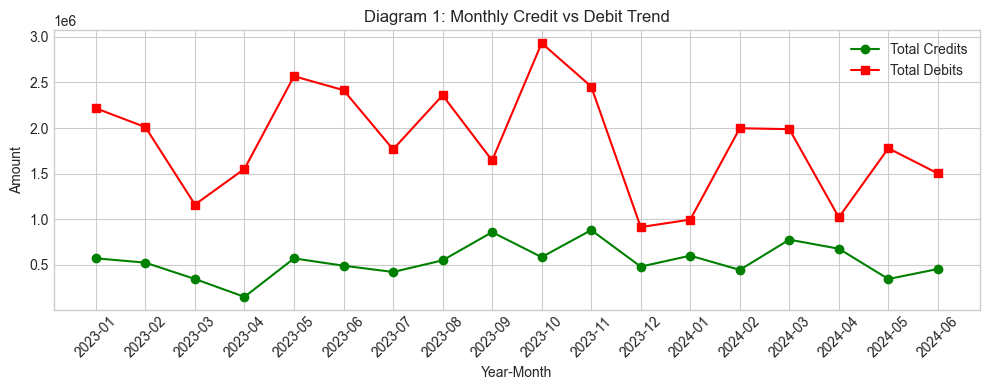

C:\Users\deepti agrawal\AppData\Local\Temp\ipykernel_15188\2211758330.py:193: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cust_profile, x='Activity_Level', order=['High', 'Medium', 'Low'], palette='Set2')


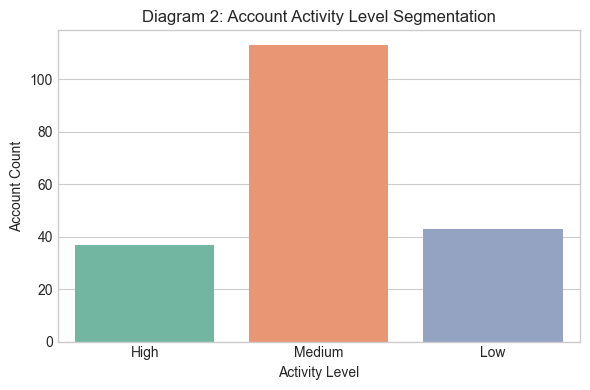

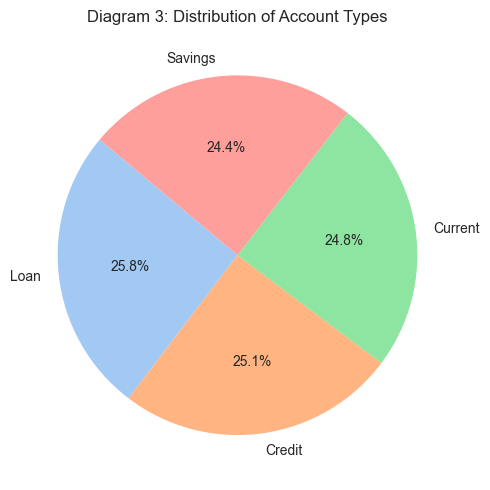

C:\Users\deepti agrawal\AppData\Local\Temp\ipykernel_15188\2211758330.py:210: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='TransactionType', palette='viridis')


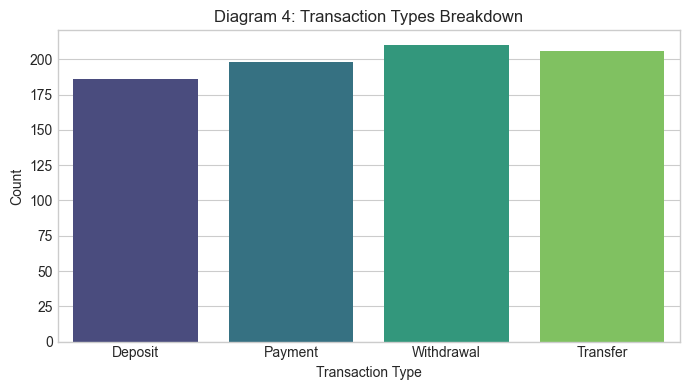

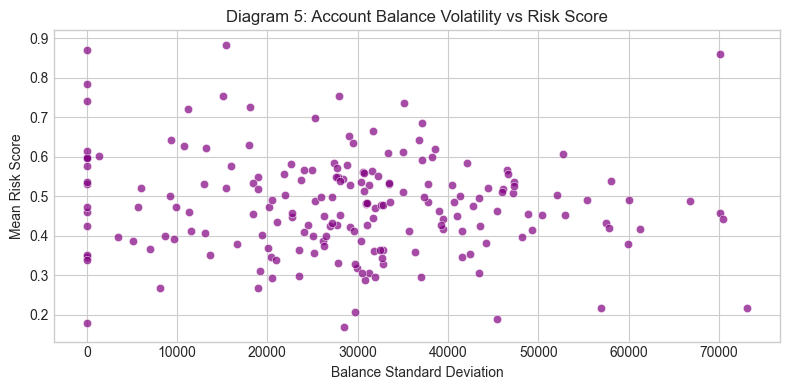

TASK 6: HYPOTHESIS TESTING RESULTS
High-Volume Mean Balance: 71919.57
Low-Volume Mean Balance:  74829.28
T-statistic: -1.2153
P-value:     0.2258
Conclusion: Fail to Reject H0 -> No statistically significant difference in average balances between high and low-volume accounts.



In [20]:
import sys
import subprocess

# Automated library installation
required_packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy']
for package in required_packages:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Chart settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


# ==============================================================================
# TASK 1: DATA CLEANING AND FORMATTING
# ==============================================================================
print("==================================================================")
print("TASK 1: DATA CLEANING AND FORMATTING")
print("==================================================================")

file_path = r"D:\python project internshala\Barclays Financial Transactional Data - barclays.csv"
df = pd.read_csv(file_path)

# Stripping whitespace from text
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# Cleaning monetary/numeric fields
for col in ['TransactionAmount', 'AccountBalance', 'RiskScore']:
    if df[col].dtype == object:
        df[col] = df[col].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Date parsing & category standardization
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d-%m-%Y', errors='coerce')
df['AccountType'] = df['AccountType'].str.title()
df['TransactionType'] = df['TransactionType'].str.title()

# Classifying credit and debit flows
df['Is_Credit'] = df['TransactionType'].isin(['Deposit'])
df['CreditAmount'] = np.where(df['Is_Credit'], df['TransactionAmount'], 0)
df['DebitAmount'] = np.where(~df['Is_Credit'], df['TransactionAmount'], 0)

print(f"-> Total Cleaned Transactions: {len(df)}")
print(f"-> Date Range: {df['TransactionDate'].min().strftime('%d-%b-%Y')} to {df['TransactionDate'].max().strftime('%d-%b-%Y')}")
print(f"-> Account Types Identified: {list(df['AccountType'].unique())}")
print(f"-> Transaction Types Identified: {list(df['TransactionType'].unique())}\n")


# ==============================================================================
# TASK 2: DESCRIPTIVE TRANSACTIONAL ANALYSIS
# ==============================================================================
print("==================================================================")
print("TASK 2: DESCRIPTIVE TRANSACTIONAL ANALYSIS")
print("==================================================================")

df['YearMonth'] = df['TransactionDate'].dt.to_period('M')

monthly_summary = df.groupby('YearMonth').agg(
    Total_Credits=('CreditAmount', 'sum'),
    Total_Debits=('DebitAmount', 'sum'),
    Net_Volume=('TransactionAmount', 'sum'),
    Transaction_Count=('TransactionID', 'count')
).reset_index()

acc_perf = df.groupby('AccountID').agg(
    Total_Credit=('CreditAmount', 'sum'),
    Total_Debit=('DebitAmount', 'sum'),
    Avg_Balance=('AccountBalance', 'mean')
).reset_index()
acc_perf['Net_Inflow'] = acc_perf['Total_Credit'] - acc_perf['Total_Debit']

top_5_accounts = acc_perf.sort_values(by='Net_Inflow', ascending=False).head(5)
bottom_5_accounts = acc_perf.sort_values(by='Net_Inflow', ascending=True).head(5)

# Dormant/Inactive account detection (Gap >= 60 days)
df_sorted = df.sort_values(by=['AccountID', 'TransactionDate'])
df_sorted['Days_Gap'] = df_sorted.groupby('AccountID')['TransactionDate'].diff().dt.days
dormant_ids = df_sorted.groupby('AccountID')['Days_Gap'].max()
dormant_accounts = dormant_ids[dormant_ids >= 60].index.tolist()

df['Is_Dormant'] = df['AccountID'].isin(dormant_accounts)

print(f"-> Total Unique Accounts Analyzed: {df['AccountID'].nunique()}")
print(f"-> Inactive/Dormant Accounts Flagged (Gap >= 60 days): {len(dormant_accounts)}")
print("\nTop 3 Performing Accounts by Net Inflow:")
print(top_5_accounts[['AccountID', 'Net_Inflow']].head(3).to_string(index=False))
print("\nBottom 3 Performing Accounts by Net Inflow:")
print(bottom_5_accounts[['AccountID', 'Net_Inflow']].head(3).to_string(index=False))
print("\n")


# ==============================================================================
# TASK 3: CUSTOMER PROFILE BUILDING
# ==============================================================================
print("==================================================================")
print("TASK 3: CUSTOMER PROFILE BUILDING")
print("==================================================================")

cust_profile = df.groupby('AccountID').agg(
    CustomerID=('CustomerID', 'first'),
    Transaction_Count=('TransactionID', 'count'),
    Avg_Balance=('AccountBalance', 'mean'),
    Total_Credit=('CreditAmount', 'sum'),
    Total_Debit=('DebitAmount', 'sum')
).reset_index()

cust_profile['Net_Inflow'] = cust_profile['Total_Credit'] - cust_profile['Total_Debit']

# Rubric Definition
def get_activity_level(count):
    if count > 5:
        return 'High'
    elif count >= 3:
        return 'Medium'
    else:
        return 'Low'

cust_profile['Activity_Level'] = cust_profile['Transaction_Count'].apply(get_activity_level)

high_inflow_threshold = cust_profile['Net_Inflow'].quantile(0.75)
high_inflow_profile = cust_profile[cust_profile['Net_Inflow'] >= high_inflow_threshold]

median_balance = cust_profile['Avg_Balance'].median()
high_freq_low_bal = cust_profile[(cust_profile['Activity_Level'].isin(['High', 'Medium'])) & 
                                 (cust_profile['Avg_Balance'] < median_balance)]

low_near_zero_bal = cust_profile[cust_profile['Avg_Balance'] <= 5000]

print("Activity Level Distribution (Rubric: High>5, Medium 3-5, Low<=2):")
print(cust_profile['Activity_Level'].value_counts().to_string())
print(f"\n-> High Net-Inflow Accounts (Top 25%): {len(high_inflow_profile)}")
print(f"-> High-Frequency Low-Balance Accounts: {len(high_freq_low_bal)}")
print(f"-> Low or Near-Zero Balance Accounts (<= 5000): {len(low_near_zero_bal)}\n")


# ==============================================================================
# TASK 4: FINANCIAL RISK IDENTIFICATION
# ==============================================================================
print("==================================================================")
print("TASK 4: FINANCIAL RISK IDENTIFICATION")
print("==================================================================")

overdraft_accs = df[df['AccountBalance'] < 0]['AccountID'].unique()

risk_df = df.groupby('AccountID').agg(
    Balance_Std=('AccountBalance', 'std'),
    Balance_Mean=('AccountBalance', 'mean'),
    RiskScore_Mean=('RiskScore', 'mean')
).fillna(0)

# IQR anomaly detection
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1
anomalies = df[(df['TransactionAmount'] < (Q1 - 1.5 * IQR)) | (df['TransactionAmount'] > (Q3 + 1.5 * IQR))]

print(f"-> Accounts with Overdraft Incidents (Negative Balance): {len(overdraft_accs)}")
print(f"-> Transactions Flagged as Anomalies (IQR Method): {len(anomalies)}")
print(f"-> Average Account Risk Score: {df['RiskScore'].mean():.4f}\n")


# ==============================================================================
# TASK 5: VISUALIZATIONS
# ==============================================================================
print("==================================================================")
print("TASK 5: GENERATING EDA VISUALIZATIONS (DISPLAYING 5 CHARTS)")
print("==================================================================")

# Chart 1: Monthly Credit vs Debit Trend
plt.figure(figsize=(10, 4))
plt.plot(monthly_summary['YearMonth'].astype(str), monthly_summary['Total_Credits'], marker='o', label='Total Credits', color='green')
plt.plot(monthly_summary['YearMonth'].astype(str), monthly_summary['Total_Debits'], marker='s', label='Total Debits', color='red')
plt.title('Diagram 1: Monthly Credit vs Debit Trend')
plt.xlabel('Year-Month')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Chart 2: Activity Level Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=cust_profile, x='Activity_Level', order=['High', 'Medium', 'Low'], palette='Set2')
plt.title('Diagram 2: Account Activity Level Segmentation')
plt.xlabel('Activity Level')
plt.ylabel('Account Count')
plt.tight_layout()
plt.show()

# Chart 3: Account Types Distribution
plt.figure(figsize=(6, 5))
acc_type_counts = df['AccountType'].value_counts()
plt.pie(acc_type_counts, labels=acc_type_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Diagram 3: Distribution of Account Types')
plt.tight_layout()
plt.show()

# Chart 4: Transaction Types Breakdown
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='TransactionType', palette='viridis')
plt.title('Diagram 4: Transaction Types Breakdown')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Chart 5: Balance Volatility vs Risk Score
plt.figure(figsize=(8, 4))
sns.scatterplot(data=risk_df, x='Balance_Std', y='RiskScore_Mean', color='purple', alpha=0.7)
plt.title('Diagram 5: Account Balance Volatility vs Risk Score')
plt.xlabel('Balance Standard Deviation')
plt.ylabel('Mean Risk Score')
plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 6: HYPOTHESIS TESTING
# ==============================================================================
print("==================================================================")
print("TASK 6: HYPOTHESIS TESTING RESULTS")
print("==================================================================")

median_count = cust_profile['Transaction_Count'].median()
high_vol = cust_profile[cust_profile['Transaction_Count'] > median_count]['Avg_Balance']
low_vol = cust_profile[cust_profile['Transaction_Count'] <= median_count]['Avg_Balance']

t_stat, p_val = stats.ttest_ind(high_vol, low_vol, equal_var=False)

print(f"High-Volume Mean Balance: {high_vol.mean():.2f}")
print(f"Low-Volume Mean Balance:  {low_vol.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: Reject H0 -> High-volume transaction accounts have statistically different average balances.")
else:
    print("Conclusion: Fail to Reject H0 -> No statistically significant difference in average balances between high and low-volume accounts.\n")


